# Deconvolve Gene Expression

In [249]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [250]:
from pipeline.CombinedDeconvolveGeneExpressionRunner \
    import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'

runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)


In [552]:
def compute_proportion_dg1(solution, config, log=True):
    dg1_tps = config.get_timepoints_for_phase('DG1')
    mg1_tps = config.get_timepoints_for_phase('CG1')
    postg1_tps = config.get_timepoints_for_phase('postG1')
    
    expression_in_postg1 = solution[config.get_Hpositions_for_phase('postG1')].max()
    expression_in_dg1 = solution[config.get_Hpositions_for_phase('DG1')].max()
    expression_in_mg1 = solution[config.get_Hpositions_for_phase('CG1')].max()

    if not log:
        expression_in_dg1 = 2**expression_in_dg1
        expression_in_mg1 = 2**expression_in_mg1
        expression_in_postg1 = 2**expression_in_postg1
        
    return expression_in_dg1, expression_in_mg1, expression_in_postg1


In [634]:
def gene_alpha_search(gene_name, kappa, replicate, alphas=None):

    if alphas is None:
        alphas = np.concatenate([np.arange(1, 8, 2), np.arange(8, 38, 1)])
    solutions = []
    dg1_tx = []
    mg1_tx = []
    postg1_tx = []
    
    print(f"Searching replicate {replicate } alphas: {gene_name}...{alphas}")

    for alpha in alphas:
        if replicate == 1:
            runner.config1.modify_alpha(alpha)
        elif replicate == 2:
            runner.config2.modify_alpha(alpha)
        find_gamma = runner.deconvolve_gene(gene_name, kappa=kappa, replicate=replicate)        
        solution = find_gamma.retrieve_solution()
        res = compute_proportion_dg1(solution, find_gamma.config)
        solutions.append(solution)
        dg1_tx.append(res[0])
        mg1_tx.append(res[1])
        postg1_tx.append(res[2])

    gene_alpha_df = pd.DataFrame({
        'DG1': dg1_tx,
        'MG1': mg1_tx,
        'postG1': postg1_tx,
        'alpha': alphas,
        'gene': [gene_name] * len(alphas),
        'replicate': [replicate]*len(alphas)
    })
    
    return gene_alpha_df


In [635]:
from src.timer import Timer
timer = Timer()
alphas = None
gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
gene_rep_results = []
for replicate in [1, 2]:
    for gene_name in gene_names:
        gene_alpha_results_df = gene_alpha_search(gene_name, kappa=0.001, 
                                          replicate=replicate, alphas=alphas)
        gene_rep_results.append(gene_alpha_results_df)
        timer.print_time()
        
all_alpha_results_df = pd.concat(gene_rep_results)
all_alpha_results_df = all_alpha_results_df.reset_index().set_index(['replicate', 'alpha', 'gene'])\
    .sort_index()


Searching replicate 1 alphas: DSE1...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:03:38.142
Searching replicate 1 alphas: DSE2...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:07:19.152
Searching replicate 1 alphas: DSE3...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:10:53.007
Searching replicate 1 alphas: DSE4...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:14:30.737
Searching replicate 2 alphas: DSE1...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:18:08.317
Searching replicate 2 alphas: DSE2...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:21:51.463
Searching replicate 2 alphas: DSE3...[ 1  3  5  7  7

In [636]:
def compute_dg1_proportion_criteria(replicate, prop_exceed=0.6):
    def compute_proportion_col1(df, col1, col2):
        total = df[col1] + df[col2]
        return df[col1]/total

    alpha_mean_results = all_alpha_results_df.loc[replicate].copy()
    
    alpha_mean_results['DG1_vs_MG1'] = compute_proportion_col1(alpha_mean_results, 'DG1', 'MG1')
    alpha_mean_results['DG1_vs_postG1'] = compute_proportion_col1(alpha_mean_results, 'DG1', 'postG1')
    alpha_mean_results['DG1_dom'] = (alpha_mean_results['DG1_vs_MG1'] > prop_exceed) & \
        (alpha_mean_results['DG1_vs_postG1'] > prop_exceed)
    return alpha_mean_results


In [ ]:
rep1_dg1_dom = compute_dg1_proportion_criteria(1, 0.65)
rep2_dg1_dom = compute_dg1_proportion_criteria(2, 0.65)

In [665]:
rep1_dg1_dom.groupby('alpha').sum()

,DG1,MG1,postG1,DG1_vs_MG1,DG1_vs_postG1,DG1_dom
alpha,,,,,,
1,53.366452,45.240227,44.057389,2.158654,2.185541,0
3,55.678249,43.477950,41.947854,2.236134,2.272185,0
5,55.379713,43.175547,40.731481,2.236929,2.295146,0
7,114.025250,84.824346,78.834623,4.560656,4.706062,0
8,56.901573,42.133403,38.849352,2.285078,2.365379,0
9,56.598762,41.843844,38.230596,2.286908,2.375926,0
10,56.139610,41.313108,37.449811,2.291357,2.387746,0
11,56.697417,41.220162,36.385161,2.301006,2.422257,0
12,57.997602,39.915762,34.903188,2.355741,2.484523,0


In [664]:

rep2_dg1_dom.groupby('alpha').sum()

,DG1,MG1,postG1,DG1_vs_MG1,DG1_vs_postG1,DG1_dom
alpha,,,,,,
1,80.066243,39.618407,37.784869,2.638860,2.682479,2
3,78.666559,38.348915,35.839624,2.660016,2.719816,3
5,80.121816,36.194562,33.696031,2.734044,2.794187,3
7,156.618284,71.178473,63.570402,5.489736,5.670915,8
8,78.731201,34.357071,30.763746,2.782458,2.868344,4
9,78.987211,33.243739,29.829318,2.815189,2.897423,4
10,78.951092,32.038807,28.701421,2.844565,2.926591,4
11,78.849039,31.066965,27.740019,2.867550,2.950796,4
12,78.588416,30.165594,26.901485,2.886834,2.970044,4


In [ ]:
all_alpha_results_df

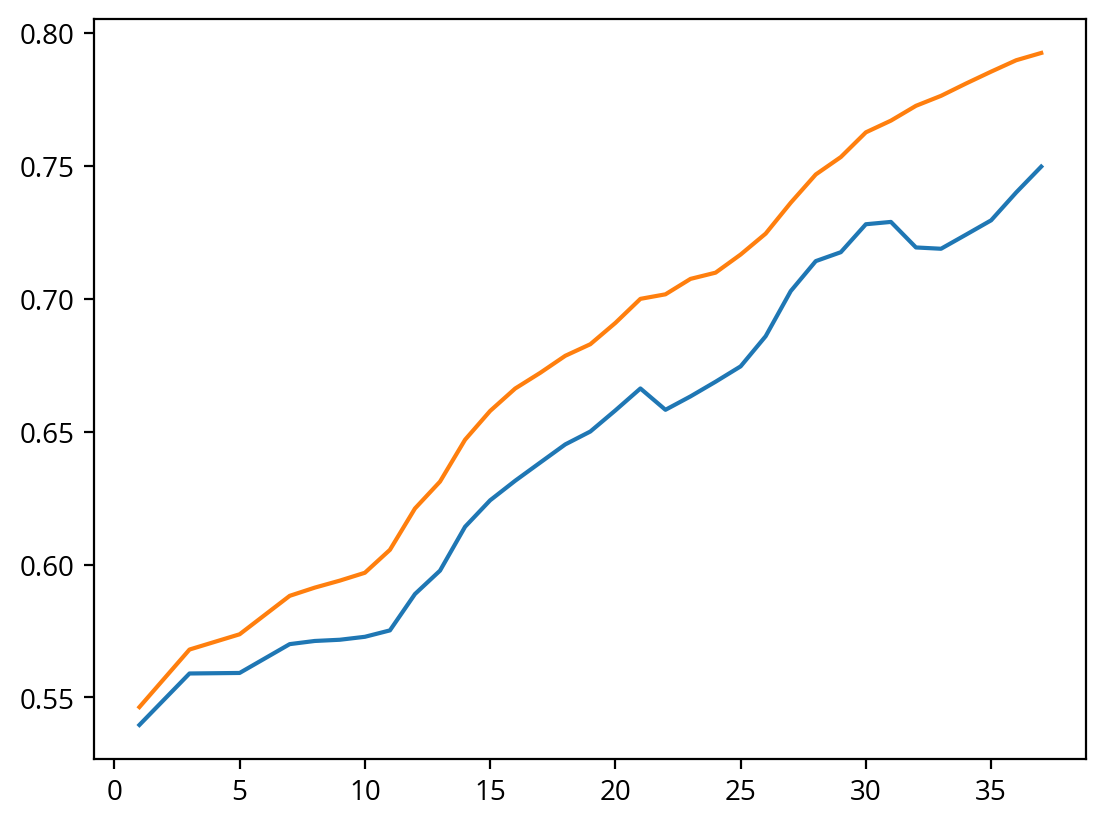

In [647]:
plt.plot(rep1_dg1_dom.groupby('alpha').mean().index, rep1_dg1_dom.groupby('alpha').mean().DG1_vs_MG1)
plt.plot(rep1_dg1_dom.groupby('alpha').mean().index, rep1_dg1_dom.groupby('alpha').mean().DG1_vs_postG1)

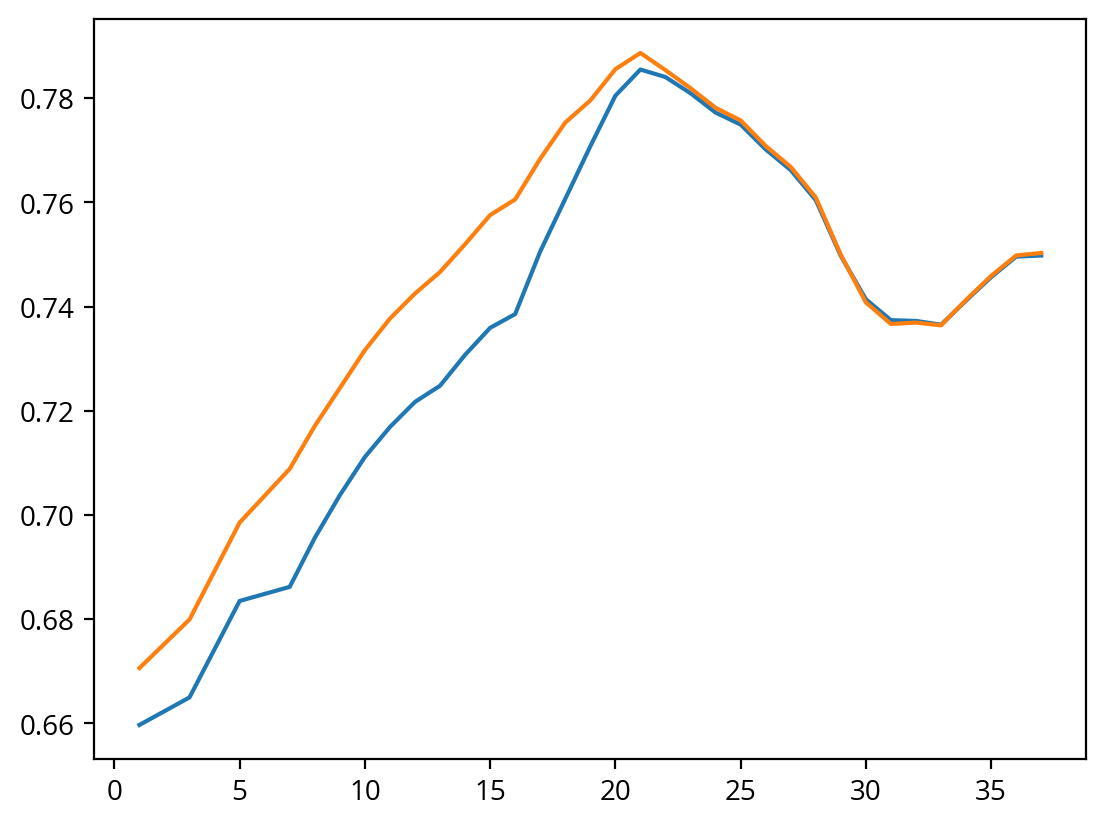

In [648]:
plt.plot(rep2_dg1_dom.groupby('alpha').mean().index, rep2_dg1_dom.groupby('alpha').mean().DG1_vs_MG1)
plt.plot(rep2_dg1_dom.groupby('alpha').mean().index, rep2_dg1_dom.groupby('alpha').mean().DG1_vs_postG1)